In [7]:
import pandas as pd

df = pd.read_csv("data/spam.csv")

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
#checking dataset
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
Index(['label', 'message'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [14]:
#counting ham and spam
df["label"].value_counts()
df.sample(10)

,label,message
3042,ham,Aight what time you want me to come up?
248,ham,Kallis wont bat in 2nd innings.
3658,ham,Studying. But i.ll be free next weekend.
4966,ham,"A few people are at the game, I'm at the mall ..."
4566,ham,Honeybee Said: *I'm d Sweetest in d World* God...
1269,spam,Can U get 2 phone NOW? I wanna chat 2 set up m...
1695,ham,Ü eatin later but i'm eatin wif my frens now l...
170,ham,Yes :)it completely in out of form:)clark also...
1357,ham,U ned to convince him tht its not possible wit...
4283,ham,U can call now...


In [15]:
#checking values
df.isnull().sum()

label      0
message    0
dtype: int64

In [17]:
## To compare ham and spam messages, I create two new columns: message_length, word_count
df["message_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda x: len(str(x).split()))

df.head()

,label,message,clean_message,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13


In [18]:
## Now I compare ham and spam messages by average length and word count.
print(df.groupby("label")[["message_length", "word_count"]].mean())
print(df.groupby("label")[["message_length", "word_count"]].median())

       message_length  word_count
label                            
ham         71.482487   14.310259
spam       138.670683   23.911647
       message_length  word_count
label                            
ham              52.0        11.0
spam            149.0        25.0


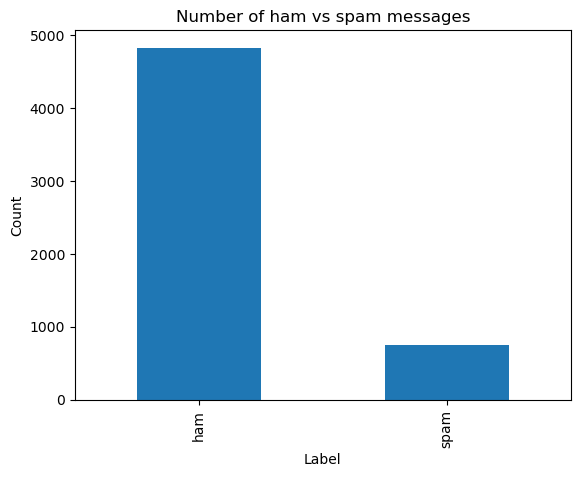

In [19]:
## visualizing the distribution between ham and spam messages
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Number of ham vs spam messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [20]:
## calculating the probability of a spam message
spam_count = (df["label"] == "spam").sum()
total_count = len(df)

spam_probability = spam_count / total_count

print("Spam count:", spam_count)
print("Total count:", total_count)
print(f"Probability of spam: {spam_probability:.2%}")

Spam count: 747
Total count: 5572
Probability of spam: 13.41%


In [ ]:
## Conclusion
In this project, I explored the SMS Spam Collection dataset using Python, pandas, and matplotlib.

### Key findings
- The dataset contains more ham messages than spam messages.
- Spam messages tend to be longer than ham messages.
- Basic exploratory data analysis can already reveal useful patterns in text data.